   Year           State  Area_hectare  Production_tonnes  \
0  2015       Karnataka         63481              76980   
1  2015          Kerala         37402              54234   
2  2015             Goa         46368              53855   
3  2015      Tamil Nadu        115122              85033   
4  2015  Andhra Pradesh        102850              31320   

   Export_quantity_tonnes  Export_value_million_usd  Yield_tonnes_per_hectare  
0                   20111                    147.08                  1.212646  
1                   28865                     99.58                  1.450029  
2                   17624                     65.28                  1.161469  
3                   15268                    246.06                  0.738634  
4                   17307                    168.88                  0.304521  

Linear Regression Results:
MAE : 0.2127676698495164
MSE : 0.05054875733420398
RMSE: 0.2248305080148243
R2  : 0.7870698757989135

Decision Tree Results:
MAE : 

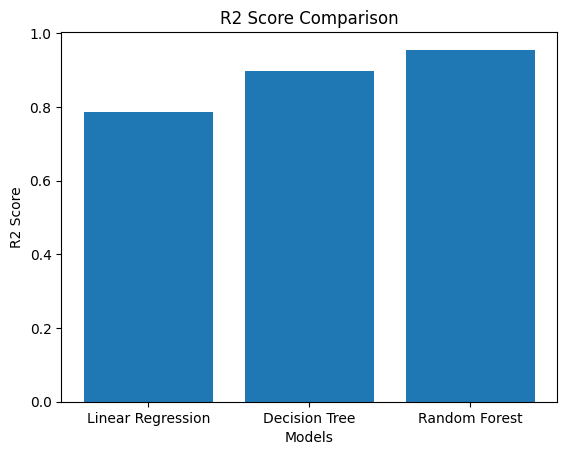

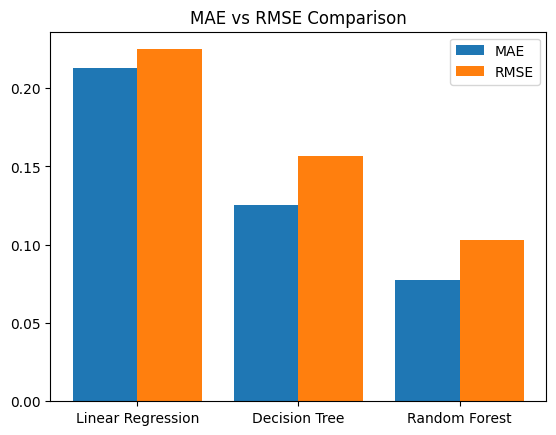

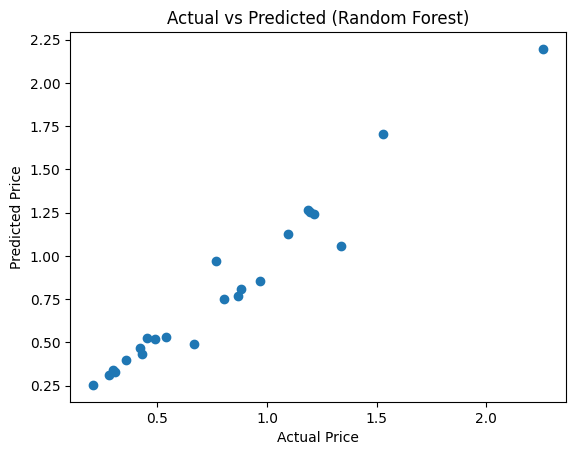

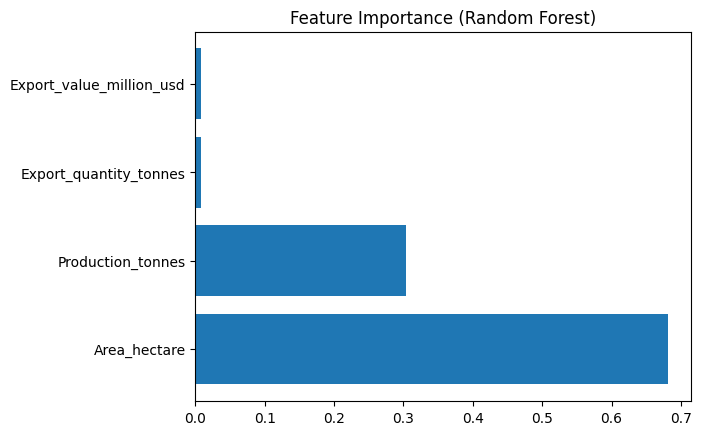

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



Sample Prediction (Area=100k, Prod=50k, Exp_Qty=10k, Exp_Val=100M USD):
Linear Regression: 0.41937156081244775
Decision Tree: 0.5859524492
Random Forest: 0.505234327628


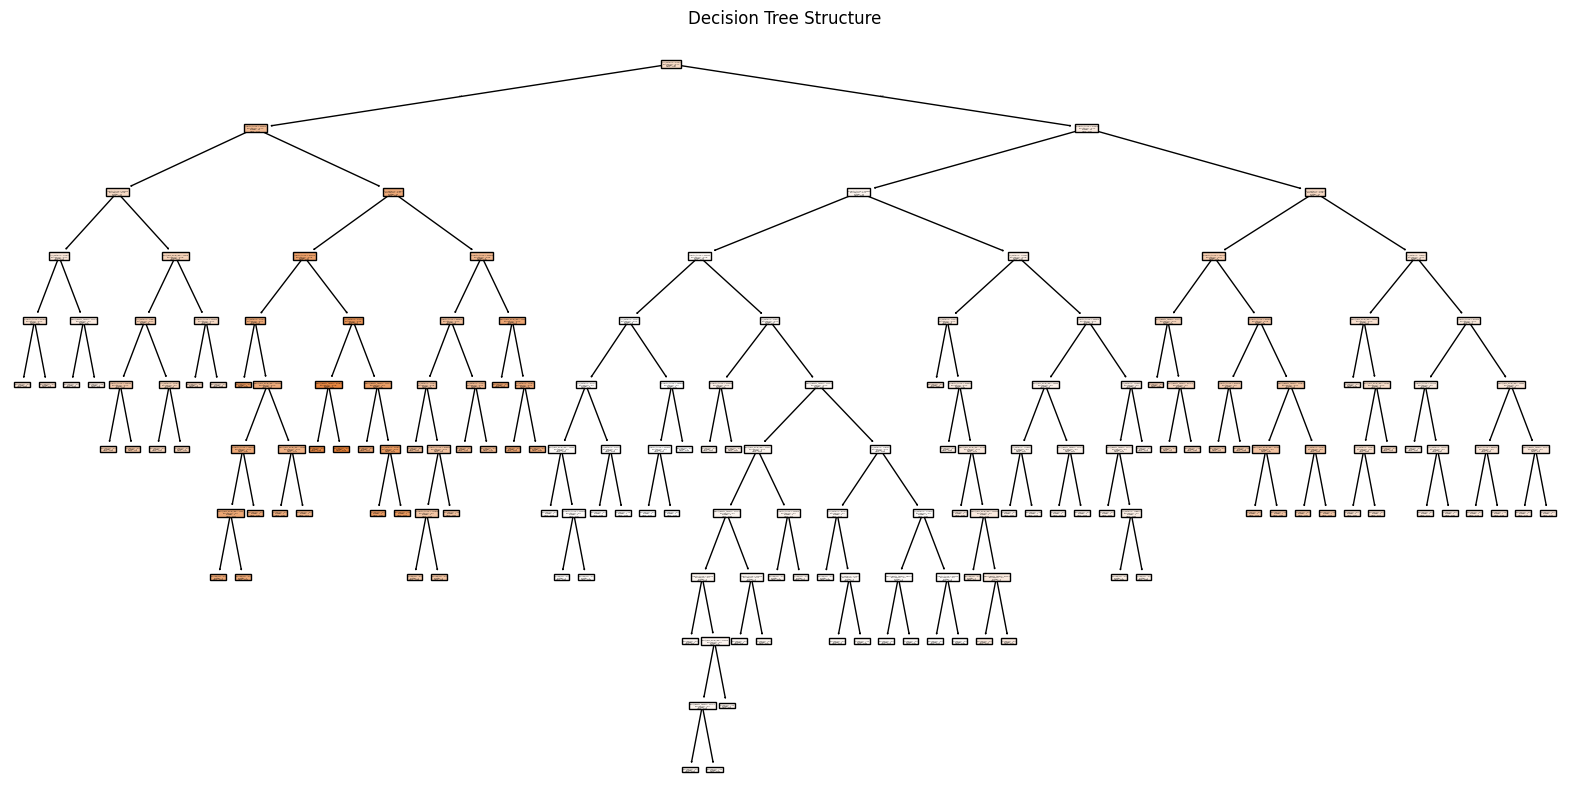

In [ ]:
# ================================
# agro ai for cashew:enhancing productivity and global export stratergies using machine learning
# ================================

# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 2: Load Dataset
df = pd.read_csv('/content/cashew_dataset_large (1).csv')

print(df.head())

# STEP 3: Define Features and Target
X = df[['Area_hectare' , 'Production_tonnes','Export_quantity_tonnes', 'Export_value_million_usd']]
y = df['Yield_tonnes_per_hectare']

# STEP 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# STEP 5: Train Models
# ================================

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# ================================
# STEP 6: Evaluation Function
# ================================

def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return mae, mse, rmse, r2

# Evaluate all models
lr_metrics = evaluate_model("Linear Regression", y_test, lr_pred)
dt_metrics = evaluate_model("Decision Tree", y_test, dt_pred)
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred)

# ================================
# STEP 7: Model Comparison Graph
# ================================

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [lr_metrics[3], dt_metrics[3], rf_metrics[3]]

plt.figure()
plt.bar(models, r2_scores)
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

# ================================
# STEP 8: MAE vs RMSE Graph
# ================================

mae_values = [lr_metrics[0], dt_metrics[0], rf_metrics[0]]
rmse_values = [lr_metrics[2], dt_metrics[2], rf_metrics[2]]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, mae_values, width=0.4, label='MAE')
plt.bar(x + 0.2, rmse_values, width=0.4, label='RMSE')

plt.xticks(x, models)
plt.title("MAE vs RMSE Comparison")
plt.legend()
plt.show()

# ================================
# STEP 9: Actual vs Predicted Graph
# ================================

plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

# ================================
# STEP 10: Feature Importance
# ================================

importance = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.show()

# ================================
# STEP 11: Sample Prediction
# ================================

# Example input for prediction (must match the 4 features used for training)
# Features: 'Area_hectare', 'Production_tonnes', 'Export_quantity_tonnes', 'Export_value_million_usd'
# Using example values: Area_hectare=100000, Production_tonnes=50000, Export_quantity_tonnes=10000, Export_value_million_usd=100
sample = np.array([[100000, 50000, 10000, 100]])

lr_out = lr.predict(sample)
dt_out = dt.predict(sample)
rf_out = rf.predict(sample)

print("\nSample Prediction (Area=100k, Prod=50k, Exp_Qty=10k, Exp_Val=100M USD):")
print("Linear Regression:", lr_out[0])
print("Decision Tree:", dt_out[0])
print("Random Forest:", rf_out[0])

# Step 12: Plot Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.title("Decision Tree Structure")
plt.show()